In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, classification_report

import warnings
warnings.filterwarnings("ignore")


In [2]:
df = pd.read_csv("indian_election_data.csv")

print("Columns:", df.columns)
df.head()


Columns: Index(['st_name', 'year', 'pc_no', 'pc_name', 'pc_type', 'cand_name',
       'cand_sex', 'partyname', 'partyabbre', 'totvotpoll', 'electors'],
      dtype='object')


,st_name,year,pc_no,pc_name,pc_type,cand_name,cand_sex,partyname,partyabbre,totvotpoll,electors
0,Andaman & Nicobar Islands,1977,1,Andaman & Nicobar Islands,GEN,K.R. Ganesh,M,Independents,IND,25168,85308
1,Andaman & Nicobar Islands,1977,1,Andaman & Nicobar Islands,GEN,Manoranjan Bhakta,M,Indian National Congress,INC,35400,85308
2,Andaman & Nicobar Islands,1980,1,Andaman & Nicobar Islands,GEN,Ramesh Mazumdar,M,Independents,IND,109,96084
3,Andaman & Nicobar Islands,1980,1,Andaman & Nicobar Islands,GEN,Alagiri Swamy,M,Independents,IND,125,96084
4,Andaman & Nicobar Islands,1980,1,Andaman & Nicobar Islands,GEN,Kannu Chemy,M,Independents,IND,405,96084


In [3]:
df.rename(columns={
    'st_name': 'State',
    'pc_name': 'Constituency',
    'cand_name': 'Candidate_Name',
    'cand_sex': 'Gender',
    'partyname': 'Party',
    'totvotpoll': 'Votes'
}, inplace=True)

df.head()


,State,year,pc_no,Constituency,pc_type,Candidate_Name,Gender,Party,partyabbre,Votes,electors
0,Andaman & Nicobar Islands,1977,1,Andaman & Nicobar Islands,GEN,K.R. Ganesh,M,Independents,IND,25168,85308
1,Andaman & Nicobar Islands,1977,1,Andaman & Nicobar Islands,GEN,Manoranjan Bhakta,M,Indian National Congress,INC,35400,85308
2,Andaman & Nicobar Islands,1980,1,Andaman & Nicobar Islands,GEN,Ramesh Mazumdar,M,Independents,IND,109,96084
3,Andaman & Nicobar Islands,1980,1,Andaman & Nicobar Islands,GEN,Alagiri Swamy,M,Independents,IND,125,96084
4,Andaman & Nicobar Islands,1980,1,Andaman & Nicobar Islands,GEN,Kannu Chemy,M,Independents,IND,405,96084


In [4]:
df['Winner'] = df.groupby(['Constituency', 'year'])['Votes'] \
                 .transform(lambda x: (x == x.max()).astype(int))

df[['Constituency', 'Votes', 'Winner']].head()


,Constituency,Votes,Winner
0,Andaman & Nicobar Islands,25168,0
1,Andaman & Nicobar Islands,35400,1
2,Andaman & Nicobar Islands,109,0
3,Andaman & Nicobar Islands,125,0
4,Andaman & Nicobar Islands,405,0


In [5]:
df.drop_duplicates(inplace=True)

# Fill missing values
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)


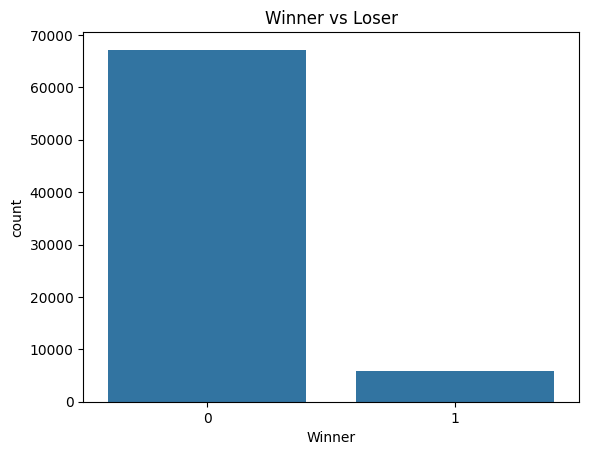

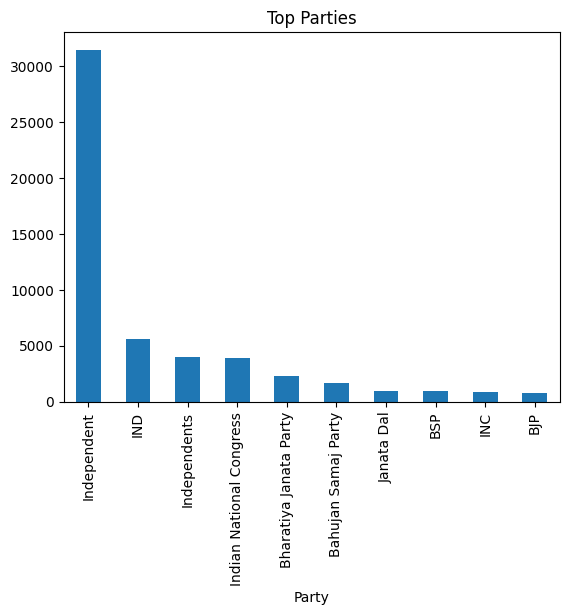

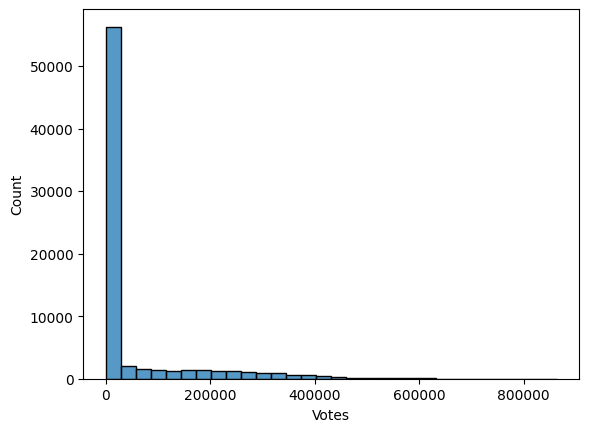

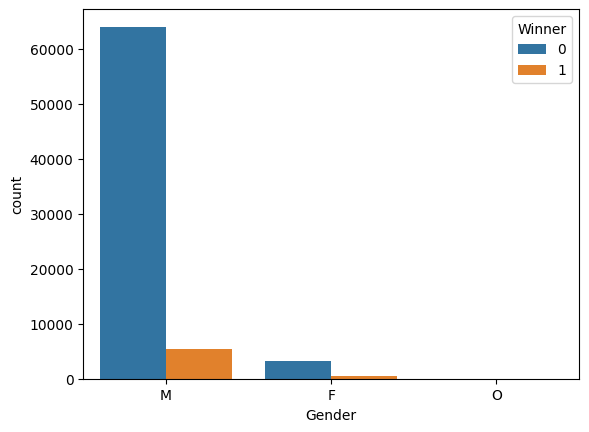

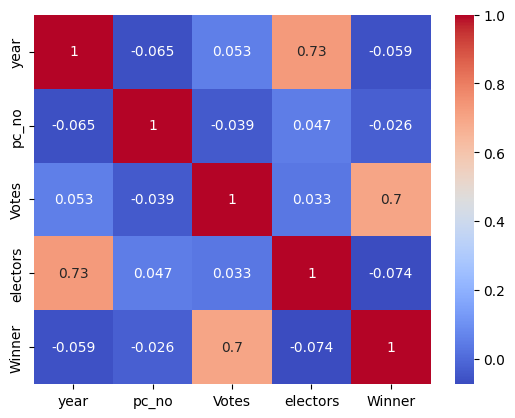

In [6]:
# Winner count
sns.countplot(x='Winner', data=df)
plt.title("Winner vs Loser")
plt.show()

# Party performance
df['Party'].value_counts().head(10).plot(kind='bar')
plt.title("Top Parties")
plt.show()

# Votes distribution
sns.histplot(df['Votes'], bins=30)
plt.show()

# Gender analysis
sns.countplot(x='Gender', hue='Winner', data=df)
plt.show()

# Correlation heatmap (FIXED)
sns.heatmap(df.select_dtypes(include=['int64','float64']).corr(),
            annot=True, cmap='coolwarm')
plt.show()


In [7]:
# Use ONLY required columns (important for app)
X = df[['Party', 'State', 'Constituency', 'Gender', 'Votes']]
y = df['Winner']


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [9]:
num_features = ['Votes']
cat_features = ['Party', 'State', 'Constituency', 'Gender']

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])


In [10]:
models = {
    "Logistic": LogisticRegression(),
    "RandomForest": RandomForestClassifier(),
    "DecisionTree": DecisionTreeClassifier(),
    "GradientBoost": GradientBoostingClassifier()
}

results = {}

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    acc = accuracy_score(y_test, preds)
    results[name] = acc

    print(f"{name} Accuracy:", acc)


Logistic Accuracy: 0.9536124794745484
RandomForest Accuracy: 0.9524493705528189
DecisionTree Accuracy: 0.9485495347564313
GradientBoost Accuracy: 0.9532703886152162


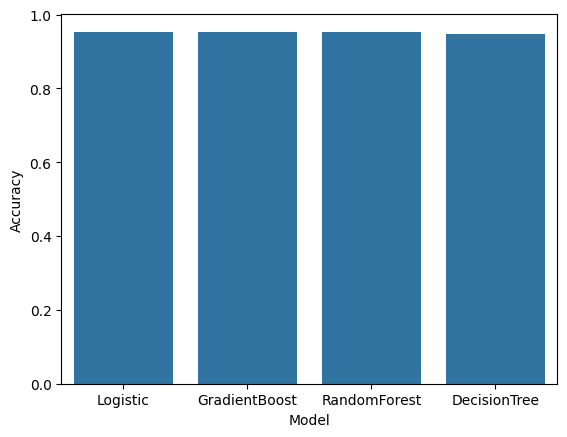

,Model,Accuracy
0,Logistic,0.953612
3,GradientBoost,0.953270
1,RandomForest,0.952449
2,DecisionTree,0.948550


In [11]:
results_df = pd.DataFrame(results.items(), columns=['Model', 'Accuracy'])
results_df.sort_values(by='Accuracy', ascending=False, inplace=True)

sns.barplot(x='Model', y='Accuracy', data=results_df)
plt.show()

results_df


In [12]:
import pickle

best_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier())
])

best_model.fit(X_train, y_train)

pickle.dump(best_model, open("voteintel_model.pkl", "wb"))

print("Model Saved Successfully ✅")


Model Saved Successfully ✅
